X_train shape: (18400, 7, 5)
y_train shape: (18400,)
Buy ratio in training data: 49.89%



/Users/anujburman/m1_tf_workspace/tf_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 128)         │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)


Training started...

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6355 - loss: 0.6317 - val_accuracy: 0.7277 - val_loss: 0.5400
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7453 - loss: 0.5111 - val_accuracy: 0.7663 - val_loss: 0.4695
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7646 - loss: 0.4797 - val_accuracy: 0.7723 - val_loss: 0.4555
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7709 - loss: 0.4655 - val_accuracy: 0.7788 - val_loss: 0.4494
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7758 - loss: 0.4599 - val_accuracy: 0.7745 - val_loss: 0.4503
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7779 - loss: 0.4545 - val_accuracy: 0.7810 - val_loss: 0.4403
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7820 - loss: 0.4511 - val_accuracy: 0.7788 - val_loss: 0.4446
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7798 - l


✅ Model saved as lstm_model.h5


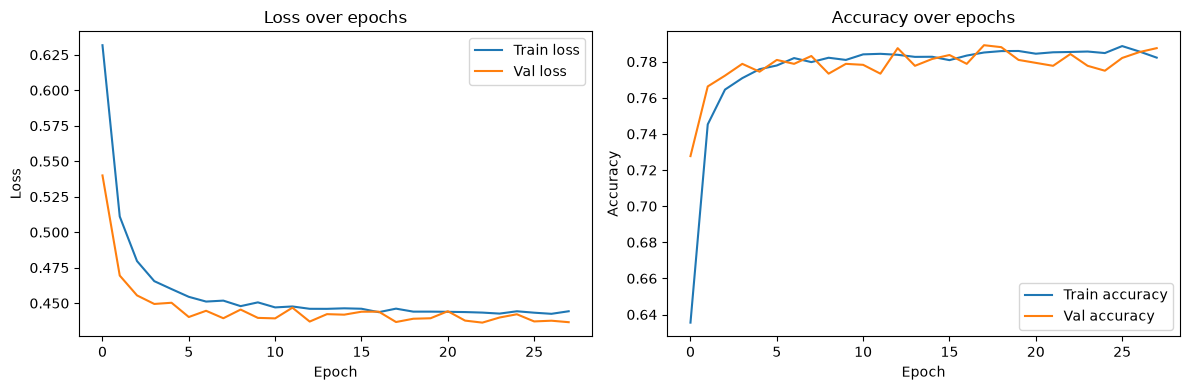

📊 Training chart saved as training_history.png


In [1]:
# model.py

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── 1. Load preprocessed data ────────────────────────────────
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

print("X_train shape:", X_train.shape)   # should be (18400, 7, 5)
print("y_train shape:", y_train.shape)   # should be (18400,)
print(f"Buy ratio in training data: {y_train.mean():.2%}\n")

# ── 2. Build the model ───────────────────────────────────────
model = Sequential([
    LSTM(128,
         input_shape=(X_train.shape[1], X_train.shape[2]),
         return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

# ── 3. Compile ───────────────────────────────────────────────
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ── 4. Print architecture summary ────────────────────────────
print("=" * 55)
model.summary()
print("=" * 55 + "\n")

# ── 5. Set up early stopping ─────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ── 6. Train ─────────────────────────────────────────────────
print("Training started...\n")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ── 7. Save the model ────────────────────────────────────────
model.save("lstm_model.h5")
print("\n✅ Model saved as lstm_model.h5")

# ── 8. Plot training history ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"],     label="Train loss")
ax1.plot(history.history["val_loss"], label="Val loss")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"],     label="Train accuracy")
ax2.plot(history.history["val_accuracy"], label="Val accuracy")
ax2.set_title("Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()
print("📊 Training chart saved as training_history.png")

In [2]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model("lstm_model.h5")
X_test = np.load("X_test.npy")

preds = model.predict(X_test[:20], verbose=0).flatten()
print("First 20 raw predictions:")
print(preds.round(4))
print("Std deviation:", preds.std())

First 20 raw predictions:
[0.9087 0.6238 0.1711 0.1155 0.8295 0.4983 0.9984 0.037  0.1498 0.7174
 0.4705 0.5992 0.9969 0.3963 0.4745 0.2223 0.927  0.7053 0.2686 0.2236]
Std deviation: 0.30615792
